# Post-fire debris-flow 2D modeling, built from scratch (non-Newtonian)

This example builds a **complete 2D HEC-RAS debris-flow model from nothing** — no
starting project — and runs a clear-water baseline plus **Bingham non-Newtonian**
mud/debris-flow variants, then derives hazard-intensity and arrival-time maps and a
parameter-sensitivity band.

**Case study:** the **Ether Hollow** post-fire watershed (Utah, 2020 fire). Inputs are
all public: the USGS post-fire debris-flow likelihood/volume predictions, a USGS 3DEP
1 m lidar DEM, and an HMS-derived design hydrograph.

**Workflow**
1. **Data** — pick the highest-hazard basin, mosaic 3DEP lidar across project
   boundaries, trace the runout corridor, reproject to a US-Customary (feet) CRS.
2. **Greenfield 2D build** — `create_project_from_template` → 2D flow area →
   roughness → computation points → inflow/outflow BC lines → terrain → mesh +
   terrain-in-mesh property tables.
3. **Clear-water baseline** — unsteady run, depth/velocity.
4. **Bingham variants** — bulk the clear-water inflow (Bulk Fluid Volume) and apply
   yield-stress/viscosity rheology.
5. **Hazard maps** — time-synchronized depth×velocity intensity + arrival time.
6. **Sensitivity** — yield stress vs Manning's n.

> **Units note.** The model is US-Customary (feet); horizontal + vertical terrain are
> in feet. **Non-Newtonian rheology is always entered in SI (Pa, Pa·s)** — HEC-RAS does
> not convert it. That mixed convention is intentional and correct.

> **Environment.** The build/run steps drive HEC-RAS (RAS Mapper / `Ras.exe`) and must
> run on Windows in an interactive desktop session. Paths below are placeholders.

## 0. Setup

In [ ]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio

from ras_commander import init_ras_project, create_project_from_template, RasCmdr, RasUnsteady
from ras_commander.terrain.Usgs3depAws import Usgs3depAws
from ras_commander.terrain.RasTerrain import RasTerrain
from ras_commander.RasMap import RasMap
from ras_commander.geom.GeomStorage import GeomStorage
from ras_commander.geom.GeomMesh import GeomMesh
from ras_commander.geom.GeomBcLines import GeomBcLines

WD   = Path("EtherHollow/proj")        # project workspace (Windows, interactive session)
DATA = Path("EtherHollow/data")        # staged inputs
CELL_FT = 33.0                          # ~10 m 2D cell size
MANNINGS_N = 0.08                       # post-fire steep terrain (see sensitivity below)

## 1. Data — basin selection, 3DEP mosaic, reproject to feet

The USGS post-fire assessment ships per-basin debris-flow **combined-hazard class** and
**volume**. We pick the highest-hazard basin, then fetch 3DEP 1 m lidar. The basin
**straddles two 3DEP projects**, so a single tile leaves a NODATA gore over the outlet —
we mosaic *both* projects (newest first, fill the gaps from the older one).

The 2D domain is the source basin **unioned with a downstream runout corridor** (a
steepest-descent trace from the outlet, buffered). The union is healed with
`make_valid` + `buffer(0)`, simplified below the cell size, and oriented CCW — a dirty
buffered-polyline perimeter otherwise makes the mesher emit zero cells. Finally the
domain + terrain are reprojected to the feet CRS and elevations converted **m → US ft**.

In [ ]:
# highest combined-hazard basin from the USGS DF predictions (15-min, 12 mm/h design storm)
basins = gpd.read_file(DATA / "burn" / "eth2020_Basin_DFPredictions_15min_12mmh.shp")
basin = basins.sort_values(["CombHaz", "Volume"], ascending=False).iloc[[0]]   # EPSG:26912 (m)

# 3DEP 1 m lidar — mosaic across the two projects the basin straddles (newest first)
import rasterio.merge
tiles = []
for proj in ["UT_Central_QL1_B2_2018", "UT_Wasatch_L5_2014"]:
    tiles += Usgs3depAws.download_tiles(tuple(basin.to_crs(4326).total_bounds), 1, DATA/"3dep",
                                        project_name=proj)
mosaic, tf = rasterio.merge.merge([rasterio.open(t) for t in tiles], method="first")

# ... trace runout corridor, union with basin, make_valid + orient(CCW), reproject to feet,
#     convert vertical m -> US survey ft, write EtherHollow_terrain_ft.tif + perimeter ring.
# (full data-phase code in the companion pipeline script)

## 2. Greenfield 2D build

This is the heart of the example: a runnable 2D mesh **from a blank template**. The
sequence is order-sensitive:

1. `create_project_from_template` — a bundled blank 7.0 project, reprojected to our feet CRS.
2. `set_2d_flow_area_perimeter` — author the 2D flow area from the domain ring.
3. `set_2d_flow_area_settings(mannings_n=…)` — base roughness (text edit, not an HDF write).
4. `generate_computation_points` — RAS Mapper point generator → seed points in the `.g01` text.
5. `GeomBcLines.add_bc_lines` — inflow line on the highest-elevation edge (basin head),
   normal-depth outflow on the lowest (fan toe).
6. `create_terrain_from_rasters` + `add_terrain_layer` — the feet DEM as a RAS terrain.
7. `compute_plan(force_geompre=True)` — HEC-RAS preprocessor builds the **mesh topology**.
8. `set_geometry_association` + `compute_property_tables` — put **terrain elevations into
   the mesh** (the step that makes `Cells Minimum Elevation` populate).

In [ ]:
prj = create_project_from_template(WD, project_name="EtherHollow", version="7.0",
                                  target_crs=feet_wkt, overwrite=True)
init_ras_project(str(WD), "7.0")
geom = WD / "EtherHollow.g01"

# 2D flow area + base roughness + computation points
GeomStorage.set_2d_flow_area_perimeter(geom_file=geom, flow_area_name="DebrisFlowArea",
        coordinates=ring, point_generation_data=[None, None, CELL_FT, CELL_FT])
GeomStorage.set_2d_flow_area_settings(geom_file=geom, flow_area_name="DebrisFlowArea",
                                      mannings_n=MANNINGS_N)
GeomMesh.generate_computation_points(str(geom), mesh_name="DebrisFlowArea", cell_size=CELL_FT)

# inflow (basin head) + normal-depth outflow (fan toe) BC lines, located by terrain elevation
GeomBcLines.add_bc_lines(geom, replace_existing=True, lines=[
    {"name": "Inflow",  "storage_area": "DebrisFlowArea", "coordinates": inflow_pts},
    {"name": "Outflow", "storage_area": "DebrisFlowArea", "coordinates": outflow_pts}])

# terrain
terrain_hdf = RasTerrain.create_terrain_from_rasters(input_rasters=[DATA/"EtherHollow_terrain_ft.tif"],
        output_folder=WD/"Terrain", terrain_name="Terrain", units="Feet", hecras_version="7.0")
RasMap.add_terrain_layer(terrain_hdf, WD/"EtherHollow.rasmap", layer_name="Terrain",
                         projection_prj=WD/"EtherHollow.projection.prj")

# mesh topology, then terrain-in-mesh property tables
RasCmdr.compute_plan("01", force_geompre=True, num_cores=2)              # builds the Voronoi mesh
GeomMesh.set_geometry_association("01", terrain_hdf_path=str(terrain_hdf))
GeomMesh.compute_property_tables("01", mesh_name="DebrisFlowArea")        # elevations into cells
# -> DebrisFlowArea: ~10,650 cells; Cells Minimum Elevation 4815-7452 ft

## 3. Clear-water baseline

The inflow is the HMS clear-water hydrograph (peak ≈ 328 cfs), placed on the `Inflow` BC
line as a Flow Hydrograph; the downstream BC is Normal Depth at the local bed slope.

> **Equation set — use Full Momentum.** All runs use the **SWE-ELM (Full Momentum)** 2D
> equation set (`UNET D2 Equation= 1`). For a non-Newtonian / mobile-bed debris flow the
> flow is inertia-dominated, rapidly varying and largely supercritical, so the convective
> and local-acceleration terms matter — **Diffusion Wave is not applicable** and is not
> shown here. (HEC-RAS defaults a new 2D plan to Diffusion Wave, so this must be set
> explicitly.) A fixed **1 s** computation interval is used; Full Momentum is well-behaved
> here (Section 6 shows 0.5–2 s give the same peaks).

The clear-water peak velocities are high (≈ 16 fps) — but they sit on the **real, smooth
40–70 % canyon thalweg**, not a structure or DEM artifact (left: the fast faces trace the
channel; right: the terrain across the worst face is a uniform ramp). HEC-RAS already
limits them well below Manning normal depth. This is the source channel's true steepness
— and, as Section 6 shows, it barely matters once the rheology is applied.

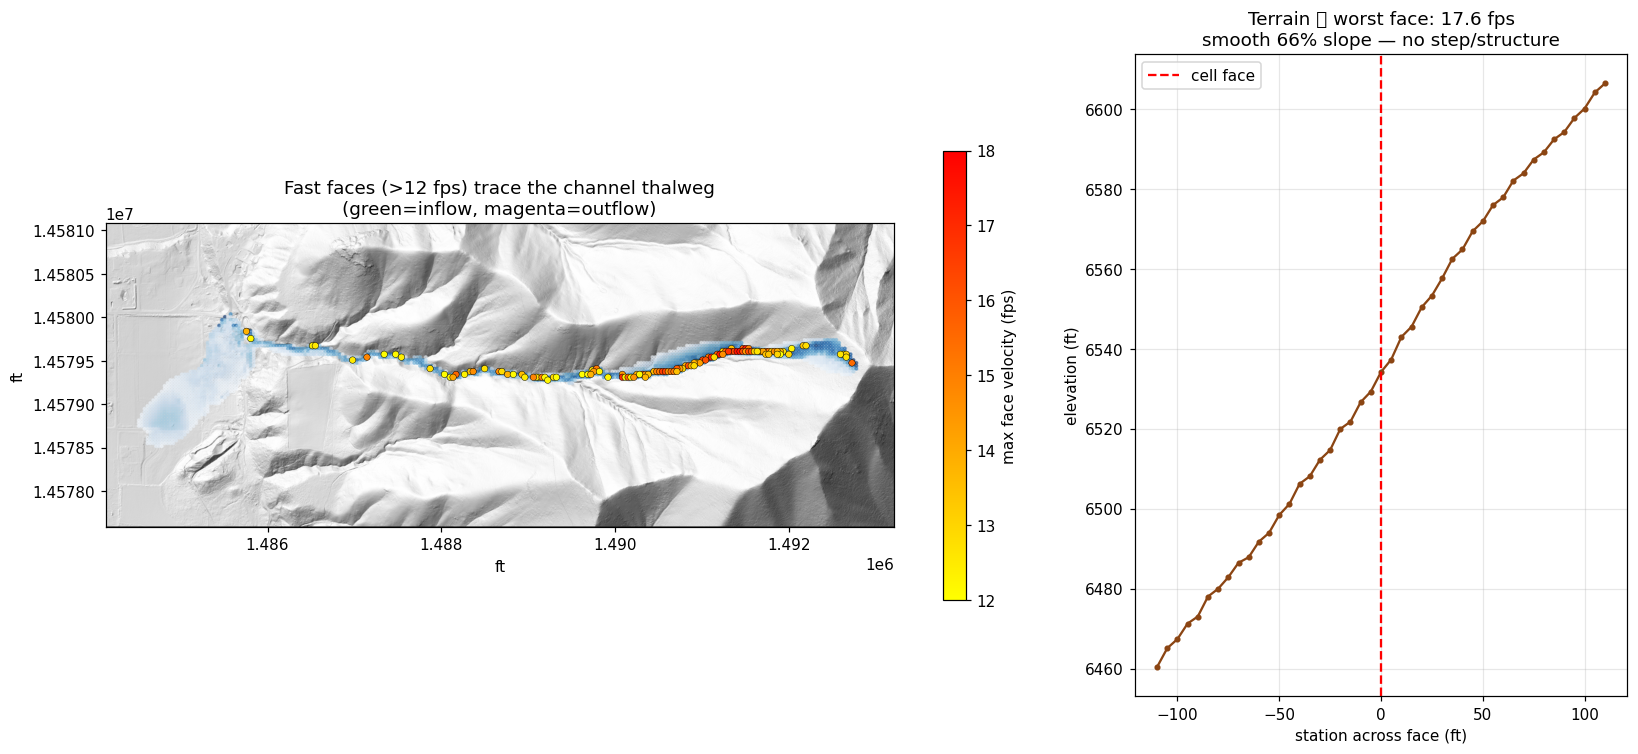

*Clear-water fast faces trace the real steep canyon thalweg (no structure / no DEM artifact).*

## 4. Bingham non-Newtonian variants

Debris flow is modeled as a **Bingham** fluid: a yield stress `τy` must be exceeded before
motion, plus a plastic viscosity `μ`. The clear-water inflow is **bulked internally** by
HEC-RAS via **Bulk Fluid Volume** at volumetric concentration `Cv` — do *not* pre-bulk the
hydrograph. At `Cv = 0.70` the bulking factor is `1/(1−Cv) = 3.33` (peak ≈ 1094 cfs of
mixture).

`RasUnsteady` exposes the non-Newtonian setters (`set_non_newtonian_method` /
`_concentration` / `_shear`); they edit an existing block, so the `.u01` must already carry
a Non-Newtonian block (initialize from a template or the GUI). Rheology is in **Pa / Pa·s**.

> **⚠️ Units gotcha.** HEC-RAS stores volumetric concentration in **percent** — pass
> `cv=70.0` for 70 %, *not* `0.70`. Writing the fraction yields `Cv = 0.7 %` and a bulking
> factor of only 1.007×. Always verify the realized inflow volume (below): bulked flow
> should be `1/(1−Cv)` times the clear-water inflow.

In [ ]:
# on the unsteady file (which already contains a Non-Newtonian block):
RasUnsteady.set_non_newtonian_method(u01, "Bingham")
RasUnsteady.set_non_newtonian_concentration(u01, cv=70.0, bulking_method="Bulk Fluid Volume")  # PERCENT
RasUnsteady.set_non_newtonian_shear(u01, yield_method="User Yield", user_yield=700.0,    # Pa
                                    visc_method="User Defined Viscosity", user_viscosity=100.0)  # Pa·s
RasCmdr.compute_plan("01", num_cores=2)

# mass-balance QA: realized inflow should bulk ~3.33x vs clear water at Cv=0.70
# clear inflow peak  ~328 cfs ;  bulked inflow peak ~1094 cfs  (1094/328 = 3.33)

**Results** (same mesh, same clear-water hydrograph bulked internally, 2 h sim):

| variant | inflow peak (cfs) | max V (fps) | max D (ft) | mean D (ft) | runout (wet cells) |
|---|---|---|---|---|---|
| Clear water | 328 | 15.8 | 13.5 | 3.0 | 1835 |
| Bingham τy = 700 Pa | 1094 | 17.3 | 19.1 | 5.6 | 1608 |
| Bingham τy = 2500 Pa | 1094 | 16.4 | 24.6 | 7.0 | 1193 |

With the inflow correctly bulked (3.33×), the debris flows carry ~3.3× the clear-water
volume: they are **fast (≈17–19 fps) and deep (≈20–24 ft)** — *more* energetic than the
clear-water baseline, not less. Higher yield stress makes the flow **deeper and slightly
less spread** (it holds together) but does not slow the peak velocity, which is set by the
bulked volume on the steep channel.

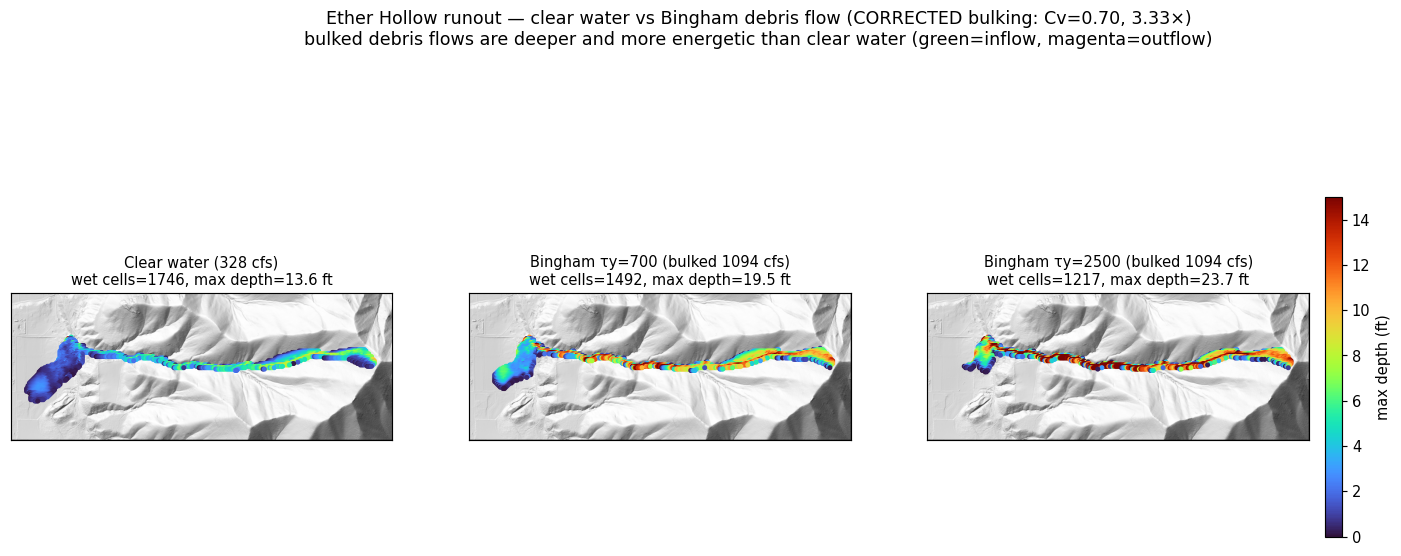

*Runout depth (corrected bulking): bulked Bingham debris flows are deeper and more energetic than clear water.*

## 5. Hazard maps — intensity and arrival time

Debris-flow **intensity** is the depth×velocity product, evaluated *time-synchronized*
(max over time of `d(t)·v(t)` per cell, not `max(d)·max(v)`), and binned into hazard
classes (High ≥ 3.3 ft or 10.8 ft²/s; Med ≥ 1.6 ft or 5.4 ft²/s). **Arrival time** is the
first time a cell wets (depth > 0.5 ft). Both come from the 121-step 2D time series in the
plan HDF.

With the corrected bulking, the debris flows are **deep, fast, and overwhelmingly
high-intensity**: ~28–30 ac of high-hazard area each, versus the clear-water baseline's
graded low→high zonation. The intensity (depth×velocity) peaks are destructive
(214–304 ft²/s).

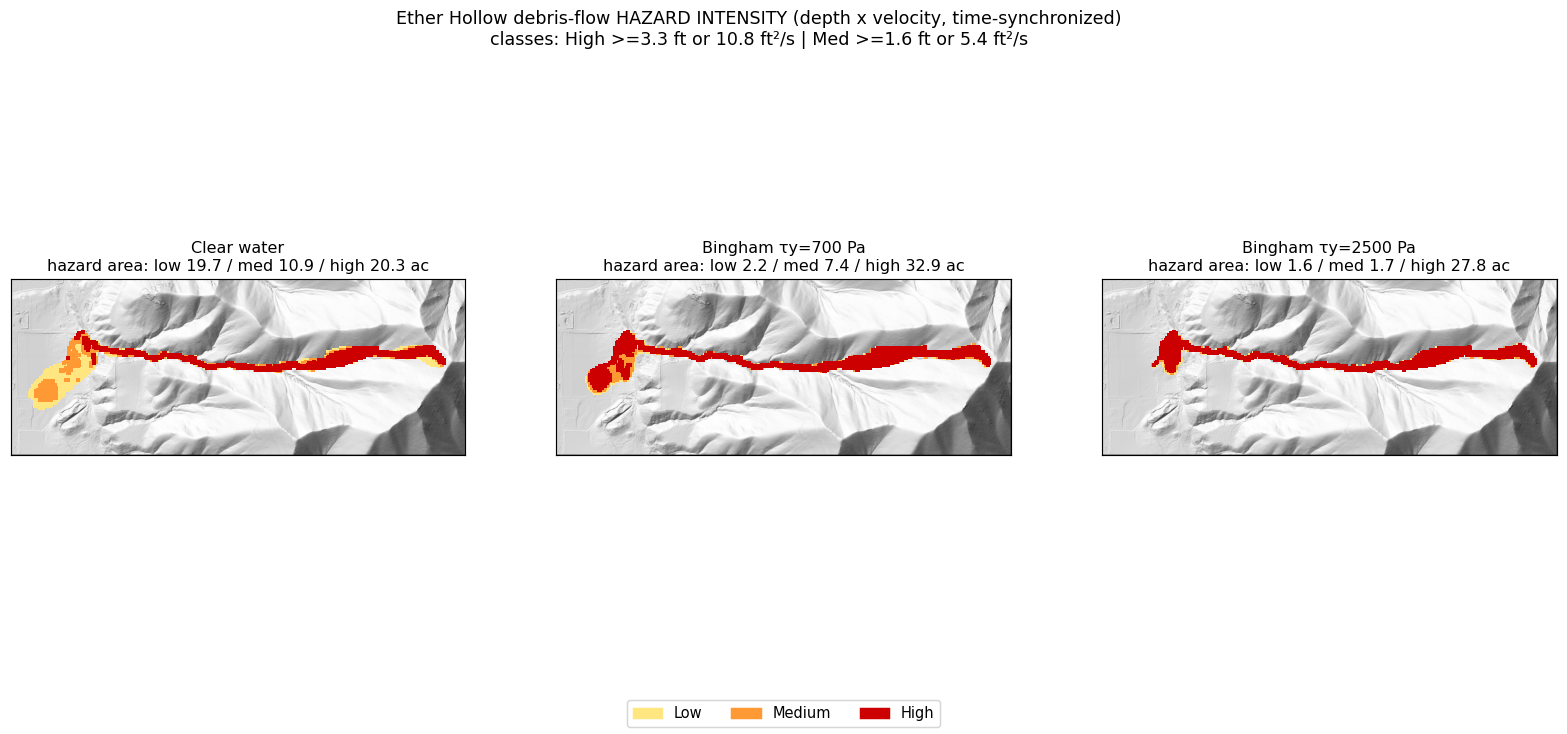

*Depth×velocity hazard intensity (corrected bulking). Bulked debris flows are almost wholly high-hazard.*

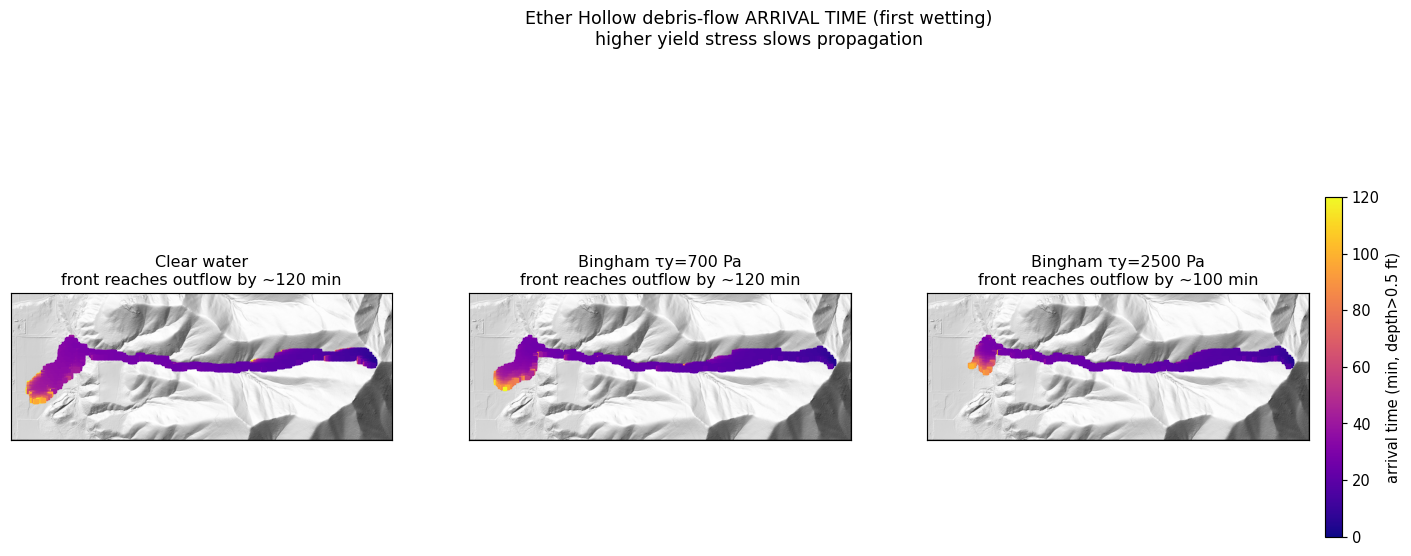

*First-wetting arrival time.*

| variant | low (ac) | med (ac) | high (ac) | total (ac) | peak intensity (ft²/s) |
|---|---|---|---|---|---|
| Clear water | 19.7 | 10.9 | 20.3 | 50.9 | 165 |
| Bingham τy = 700 | 2.2 | 7.4 | 32.9 | 42.4 | 254 |
| Bingham τy = 2500 | 1.6 | 1.7 | 27.8 | 31.0 | 240 |

## 6. Convergence and parameter sensitivity

**Numerical convergence.** With the Full Momentum solver the run is **well-converged in
time** — 0.5, 1, and 2 s all give the same peaks (max V ≈ 17.3 fps, max D ≈ 19.1 ft). The
SWE-ELM scheme is more stable here than Diffusion Wave (which went unstable at 2 s). A 1 s
interval is used as a comfortable margin.

**Parameter sensitivity** (reference: τy = 700 Pa, Cv = 0.70, μ = 100 Pa·s, 1 h, 1 s; one
parameter varied per panel):

- **Concentration / bulking (Cv)** is a leading control — 0.40 → 0.70 raises the bulked
  inflow 547 → 1094 cfs and max velocity 12.8 → 17.3 fps, expanding runout.
- **Viscosity** matters — μ 10 → 1000 Pa·s drops max velocity 19.0 → 10.7 fps.
- **Yield stress** controls depth and extent (τy 700 → 2500: max depth 19.1 → 23.2 ft,
  runout 1539 → 1131 cells) more than velocity.

This is a genuine multi-parameter sensitivity; **Cv and viscosity are at least as
influential as yield stress**, so a defensible study must vary all three (plus mesh and
roughness — see limitations).

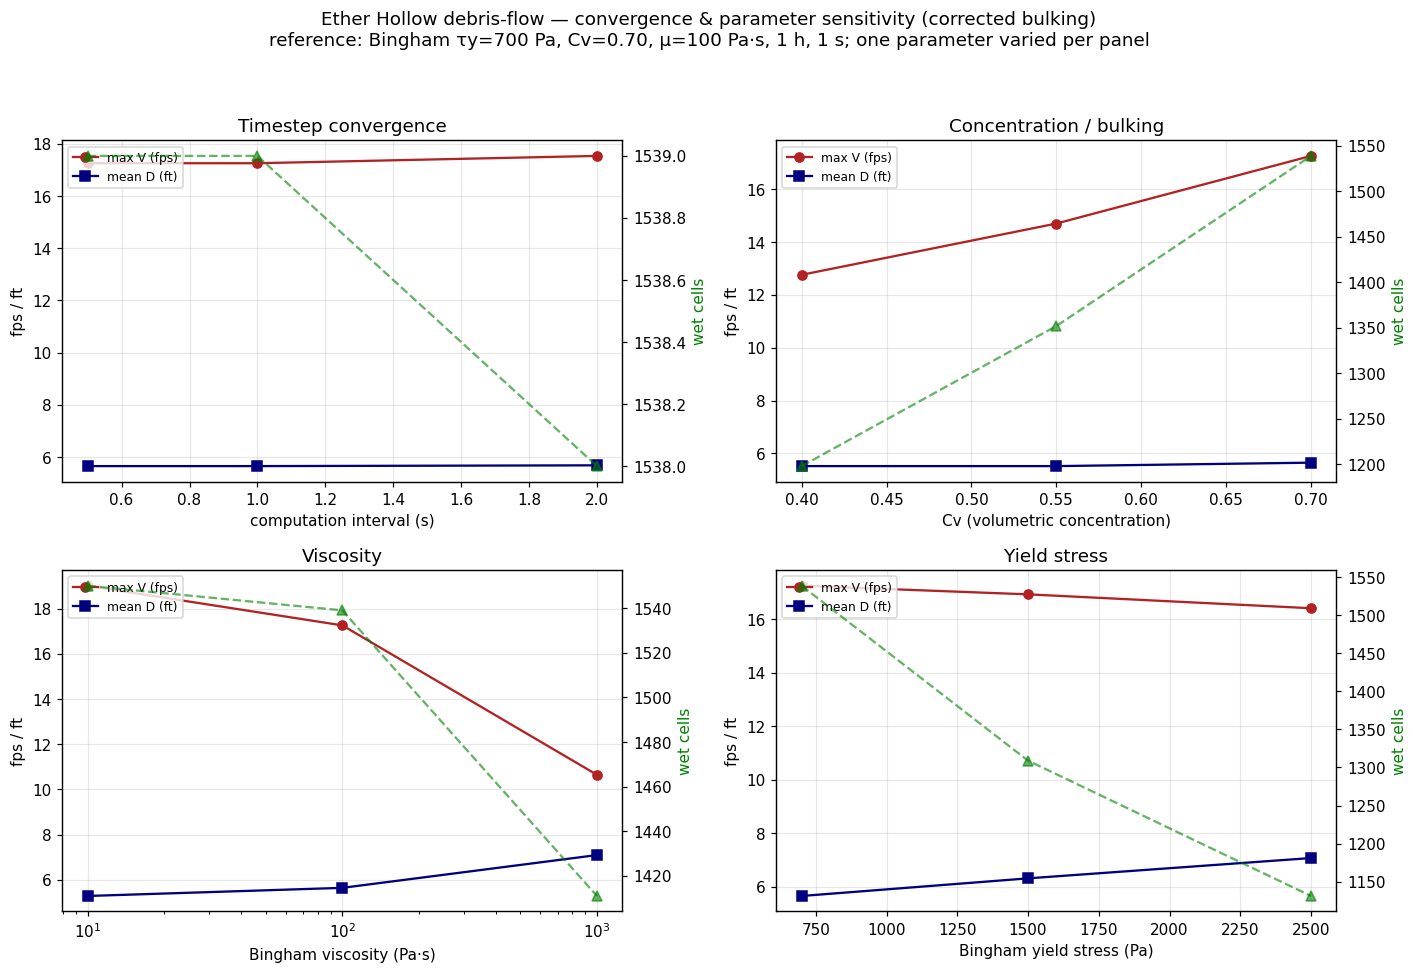

*Convergence (timestep) + sensitivity to Cv, viscosity, and yield stress (corrected bulking).*

### Mesh convergence, roughness, and inflow placement (Full Momentum)

Further studies (Bingham τy = 700 Pa, Cv = 0.70, bulked, SWE-ELM):

- **Mesh convergence** (timestep scaled to hold the Courant number ~constant — 16.5 ft @
  0.25 s, 33 ft @ 1 s, 66 ft @ 2 s): **peak velocity is converged** (≈15.5–18.4 fps across
  resolutions). Max depth and runout *extent* are moderately mesh-sensitive — a coarser mesh
  over-predicts extent (≈32 / 38 / 52 ac at 16.5 / 33 / 66 ft). 33 ft is a reasonable
  compromise; report extent with a ~±25 % mesh band. (Mesh and timestep must refine together:
  a *fixed* 1 s step at 16.5 ft is Courant-unstable.)
- **Manning's n** (re-bulked): affects velocity ~30 % (n 0.06 → 0.10) but leaves depth and
  runout extent essentially unchanged — roughness is a second-order control for the debris flow.
- **Inflow placement** is a *first-order* choice: injecting at the basin **head** routes the
  full bulked flow down the entire steep channel (max V 17.3, max D 19.1, 1539 cells);
  injecting at the basin **outlet / fan apex** — consistent with the HMS hydrograph being the
  basin's outlet response — roughly **halves** every metric (10.0 / 12.5 / 732). The outlet
  placement is arguably the more defensible conceptual model for a runout study.

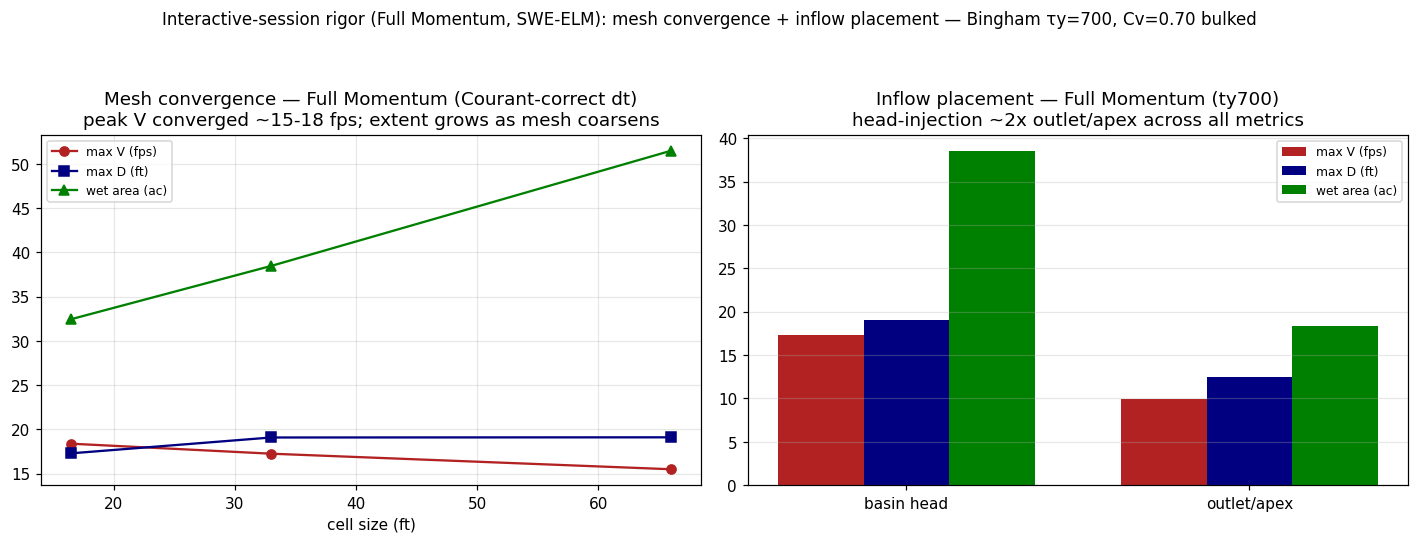

*Mesh convergence (Courant-correct) and inflow placement, Full Momentum.*

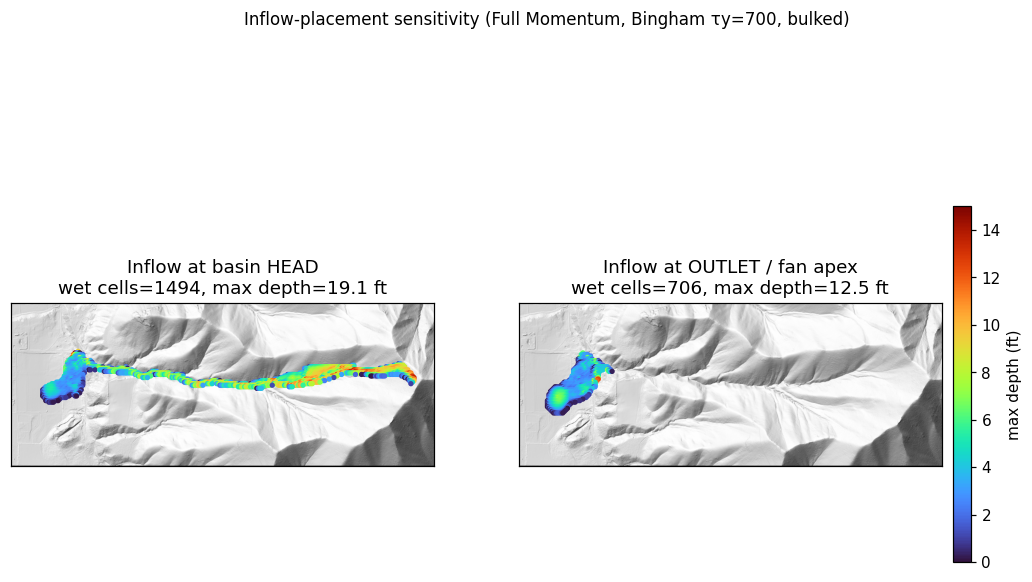

*Inflow placement: head-injection sends the full flow down the steep basin channel; outlet-injection only loads the fan.*

## 6b. Channel breaklines — refining the mesh along the thalweg

The mesh studies above flagged a **resolution artifact**: a uniform 33 ft cell averaged
across a narrow, deep channel piles water artificially, over-predicting depth on the thalweg.
The fix is to **align cell faces to the channel centerline** with breaklines.

**Delineation (TauDEM).** `delineate_channels.py` runs the TauDEM stream sequence
(PitRemove → D8FlowDir → AreaD8 → Threshold → StreamNet) on the feet terrain, clips the
centerlines to the 2D domain, and simplifies them (Douglas-Peucker, 10 ft).

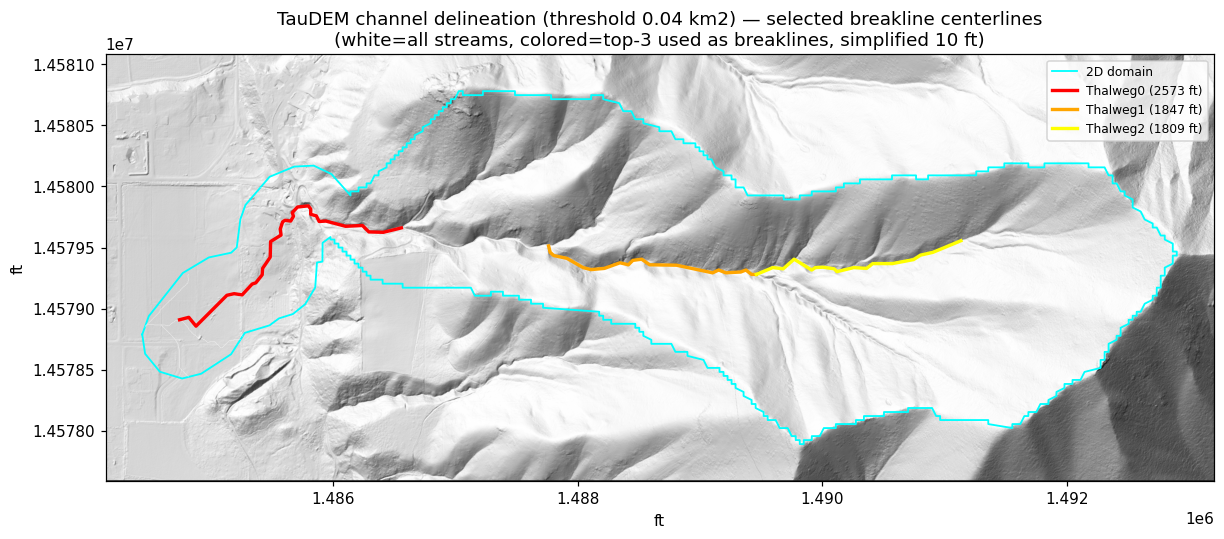

*TauDEM channel delineation (flow-accumulation threshold 0.04 km²): white = all streams, colored = top-3 centerlines used as breaklines, cyan = 2D domain.*

**Authoring + enforcement.** The build phase authors the centerlines via
`GeomStorage.set_breaklines` with **near = far** cell spacing (a uniform fine corridor, no
coarsening) and `GeomMesh.set_breakline_spacing(near_repeats, protection_radius=1)` — sizing
`near_repeats` to span the channel width for a constant-width refined band.
`GeomMesh.generate` then enforces the breaklines (the .NET `EnforceBreaklines` regen) and
repairs bad faces via its auto-fix loop; `HdfBndry.get_breaklines` confirms enforcement.

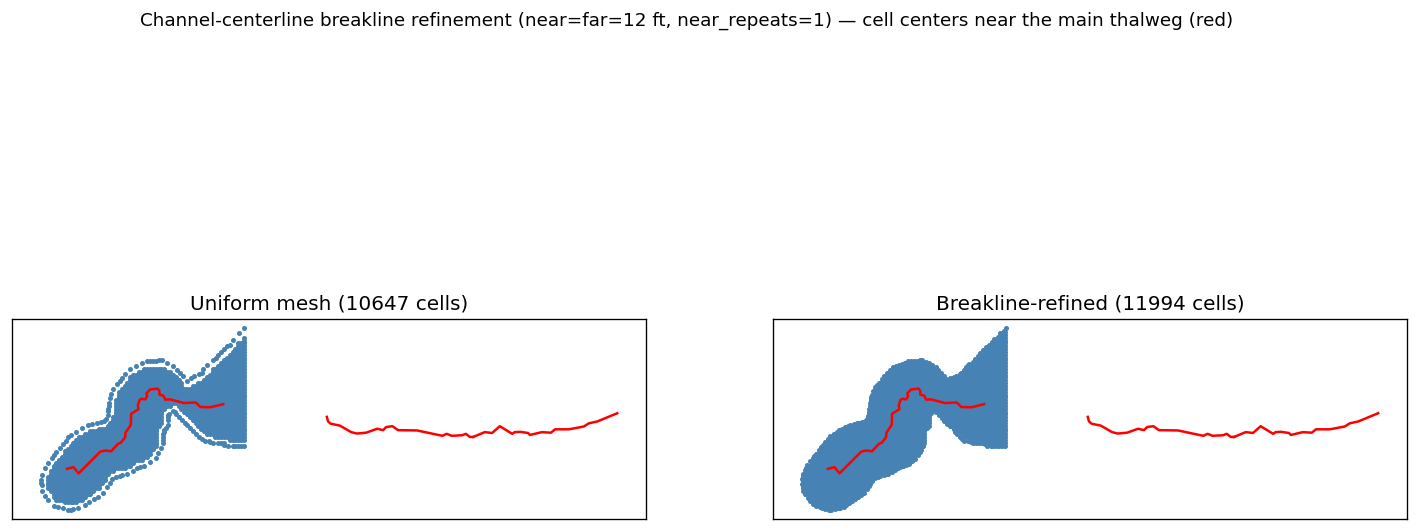

*Cell centers near the main thalweg (red): uniform vs breakline-refined (near=far=12 ft, near_repeats=1). The corridor follows the channel centerline.*

**Effect** (τy = 700 Pa, Full Momentum, identical conditions):

| metric | uniform 33 ft | breakline-refined |
|---|---|---|
| max velocity (fps) | 17.3 | 17.7 |
| **max depth (ft)** | **19.1** | **15.9** |
| mean depth (ft) | 5.65 | 5.74 |
| cells | 10,647 | 11,994 |

The channel-aligned refinement drops the spurious max depth **19.1 → 15.9 ft** while peak
velocity stays stable (~17.5 fps) — the resolution artifact is removed where it matters.
TauDEM 5.x + MS-MPI are required for the delineation (CPU-only; can run off the HEC-RAS host).

## 7. Mass balance and limitations

**Mass balance.** The clear-water hydrograph integrates to ~13,400 m³ of water; at
Cv = 0.70 that implies ~31,000 m³ of debris — about **3.5× the USGS empirically predicted
debris-flow volume (~9,000 m³)** for this basin, and the HMS peak (328 cfs) exceeds the
BAER-reported mouth range (~82–221 cfs). **These outputs are therefore an uncalibrated,
upper-bound scenario, not a calibrated prediction.** A volume- or peak-matched inflow would
shrink the footprints.

**Remaining for an engineering-grade product** (this notebook is a methods demonstration;
convergence, roughness, inflow-placement, and multi-parameter sensitivity are covered above):
an **equation-set** comparison (full
momentum vs. diffusion wave); a **cell-centered** (vs. face-max) velocity for intensity; a
volume-/peak-matched inflow to the USGS prediction; and **validation** against observed
Ether Hollow deposits / a benchmark case.

## Summary

Starting from public USGS/3DEP data and a blank template, ras-commander built a complete
2D debris-flow model end-to-end: greenfield mesh + terrain-in-mesh, inflow/outflow BCs,
a clear-water baseline, Bingham non-Newtonian variants with internal bulking, and
hazard-intensity / arrival-time products with a parameter-sensitivity band.

**Key engineering findings**
- The from-scratch 2D greenfield path is the seed-points → preprocess → terrain-in-mesh
  sequence; perimeter validity (`make_valid`/orient/simplify) is essential for the mesher.
- Clear-water velocities are high on the genuinely steep canyon thalweg — real terrain, not
  an artifact — and should not be "fixed" by editing the ground.
- **Verify bulking with a mass balance.** Volumetric concentration is entered in *percent*;
  a fraction silently disables bulking. Correctly bulked (3.33×), the debris flows are fast
  (≈17–19 fps) and deep (≈20–24 ft), with depth/extent set by yield stress and velocity by
  the bulked volume and viscosity.
- Treat the footprints as an **uncalibrated upper-bound scenario** (≈3.5× the USGS volume)
  pending mesh/inflow/equation-set studies and field validation.